# Homework 6: Flow matching models

## Task 1: Theory (6 pts)

### Problem 1: Linear Vector Fields (1 pt)

This problem is a warm-up for continuous-time generative models. Before working with complicated neural vector fields, it is useful to understand how a simple ODE transports samples, how to invert the flow, and how the density changes through the Jacobian of this map.

Consider the ODE
$$
\frac{d \mathbf{x}(t)}{dt} = \mathbf{u}_t(\mathbf{x}(t)), \qquad \mathbf{u}_t(\mathbf{x}) = -\theta \mathbf{x}, \qquad \theta > 0,
$$
where $\mathbf{x}(t) \in \mathbb{R}^d$.

Define
$$
\boldsymbol{\psi}_t(\mathbf{x}_0) = e^{-\theta t} \mathbf{x}_0.
$$

1. Show that $\boldsymbol{\psi}_t$ is the flow of this ODE, that is, verify both the initial condition $\boldsymbol{\psi}_0(\mathbf{x}_0) = \mathbf{x}_0$ and the differential equation
$$
\frac{d}{dt}\boldsymbol{\psi}_t(\mathbf{x}_0) = \mathbf{u}_t(\boldsymbol{\psi}_t(\mathbf{x}_0)).
$$
2. Find the inverse flow $\boldsymbol{\psi}_t^{-1}(\mathbf{x})$.
3. Let $\mathbf{x}_0 \sim p_0$. Using the change-of-variables formula, derive the density $p_t(\mathbf{x})$ of $\mathbf{x}(t) = \boldsymbol{\psi}_t(\mathbf{x}_0)$.
4. What is $p_t(\mathbf{x})$ when $p_0 = \mathcal{N}(0, \mathbf{I})$? What happens to the trajectories and the distribution as $t \to \infty$?


```your solution```

### Problem 2: Reverse-Time SDE from Bayes' Rule (3 pts)

Diffusion models are trained by adding noise forward in time, but generation requires running the process backward. The rigorous reverse-time SDE theorem is technical; in this problem we derive its form heuristically and see why the score function appears as the correction to the forward drift.

Consider the forward SDE in $\mathbb{R}^d$
$$
d\mathbf{x} = \mathbf{f}(\mathbf{x}, t)\,dt + g(t)\,d\mathbf{w},
$$
and assume that for a small $\Delta t > 0$ its Euler transition is
$$
p(\mathbf{x}_{t+\Delta t} \mid \mathbf{x}_t)
=
\mathcal{N}\left(
\mathbf{x}_{t+\Delta t};
\mathbf{x}_t + \mathbf{f}(\mathbf{x}_t,t)\Delta t,
g^2(t)\Delta t\,\mathbf{I}
\right).
$$
Denote the marginal density of $\mathbf{x}_t$ by $p_t(\mathbf{x})$ and the score by
$$
\mathbf{s}_t(\mathbf{x}) = \nabla_{\mathbf{x}} \log p_t(\mathbf{x}).
$$

Our goal is to understand why the reverse-time SDE contains the score term.

1. Using Bayes' rule, write $p(\mathbf{x}_t \mid \mathbf{x}_{t+\Delta t})$ in terms of the forward transition and the marginals $p_t$, $p_{t+\Delta t}$.
2. Let $\boldsymbol{\delta} = \mathbf{x}_{t+\Delta t} - \mathbf{x}_t$. Apply the first-order Taylor expansion of $\log p_{t+\Delta t}(\mathbf{x}_{t+\Delta t})$ around $(\mathbf{x}_t,t)$ and substitute it into Bayes' rule.
3. Complete the square in $\boldsymbol{\delta}$ and show that, up to first-order terms in $\Delta t$,
$$
p(\mathbf{x}_t \mid \mathbf{x}_{t+\Delta t})
\approx
\mathcal{N}\left(
\mathbf{x}_t;
\mathbf{x}_{t+\Delta t}
-
\left[
\mathbf{f}(\mathbf{x}_{t+\Delta t},t+\Delta t)
-
g^2(t+\Delta t)\mathbf{s}_{t+\Delta t}(\mathbf{x}_{t+\Delta t})
\right]\Delta t,
 g^2(t+\Delta t)\Delta t\,\mathbf{I}
\right).
$$
4. Use this discrete reverse transition to write the reverse-time SDE. Explain the sign convention for $dt$.

**Hint:** terms that multiply the density by $1 + O(\Delta t)$ may change the normalization constant but do not change the leading-order drift and diffusion coefficients.

```your solution```

### Problem 3: Posterior of the Forward Process in Discrete Diffusion (2 pts)

In [Lecture 12](https://github.com/r-isachenko/2026-DGM-AIMasters-course/blob/main/lectures/lecture12/Lecture12.pdf) we defined a discrete diffusion process for one categorical token. The state at time $t$ is represented by a one-hot column vector
$$
\mathbf{x}_t \in \{0,1\}^K.
$$
The forward process is a Markov chain
$$
q(\mathbf{x}_t | \mathbf{x}_{t-1}) = \mathrm{Cat}(\mathbf{Q}_t \mathbf{x}_{t-1}),
$$
where $\mathbf{Q}_t \in [0,1]^{K \times K}$ is a column-stochastic transition matrix:
$$
[\mathbf{Q}_t]_{ij} = q(x_t=i | x_{t-1}=j),
\qquad
\sum_{i=1}^K [\mathbf{Q}_t]_{ij}=1.
$$
We also use the notation
$$
\mathbf{Q}_{1:t}=\mathbf{Q}_t\mathbf{Q}_{t-1}\cdots\mathbf{Q}_1,
\qquad
q(\mathbf{x}_t | \mathbf{x}_0)=\mathrm{Cat}(\mathbf{Q}_{1:t}\mathbf{x}_0).
$$

The reverse model $p_{\boldsymbol{\theta}}(\mathbf{x}_{t-1}|\mathbf{x}_t)$ is learned, but the conditioned reverse distribution of the forward process
$$
q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)
$$
is tractable. Your goal is to derive it.

1. Using Bayes' rule and the Markov property, show that
$$
q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)
=
\frac{q(\mathbf{x}_t|\mathbf{x}_{t-1})q(\mathbf{x}_{t-1}|\mathbf{x}_0)}{q(\mathbf{x}_t|\mathbf{x}_0)}.
$$
2. For a candidate previous state $\mathbf{x}_{t-1}=\mathbf{e}_j$, express each of the three probabilities in the formula above through $\mathbf{Q}_t$, $\mathbf{Q}_{1:t-1}$, $\mathbf{Q}_{1:t}$, $\mathbf{x}_t$, and $\mathbf{x}_0$.
3. Derive the categorical distribution over $\mathbf{x}_{t-1}$:
$$
q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)
=
\mathrm{Cat}\left(
\frac{(\mathbf{Q}_t^{\top}\mathbf{x}_t) \odot (\mathbf{Q}_{1:t-1}\mathbf{x}_0)}
{\mathbf{x}_t^{\top}\mathbf{Q}_{1:t}\mathbf{x}_0}
\right),
$$
where $\odot$ denotes elementwise multiplication.

**Note:** the transpose appears because we use the column-vector convention from the lectures: the columns of $\mathbf{Q}_t$ are conditional distributions of $\mathbf{x}_t$ given a fixed previous state. If one uses row one-hot vectors and row-stochastic transition matrices, the same formula is written with the corresponding transposed convention.

```your solution```

In [ ]:
COMMIT_HASH = "1ecc005234d1a57d8d52e7a852ebe239cb0f9860"
!if [ -d dgm_utils ]; then rm -Rf dgm_utils; fi
!git clone https://github.com/r-isachenko/dgm_utils.git
%cd dgm_utils
!git checkout {COMMIT_HASH}
!pip install ./
%cd ./..
!rm -Rf dgm_utils

In [1]:
from dgm_utils import load_dataset, BaseModel, train_model
from dgm_utils import visualize_images, show_samples, LabeledDataset

In [2]:
from typing import Dict, List, Optional, Tuple
from tqdm.auto import tqdm

import numpy as np
import ot as pot

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

from torchdiffeq import odeint

if torch.cuda.is_available():
    DEVICE = "cuda"
    print('GPU found :)') 
else: 
    DEVICE = "cpu"
    print('GPU not found :(')

GPU found :)


## Task 2: Flow matching on CIFAR10 (4 pts) 

In this task, you will train **Flow matching** model, focusing on its sampling capabilities. See the [Lecture 10](https://github.com/r-isachenko/2026-DGM-AIMasters-course/blob/main/lectures/lecture10/Lecture10.pdf), [Lecture 11](https://github.com/r-isachenko/2026-DGM-AIMasters-course/blob/main/lectures/lecture11/Lecture11.pdf) and [paper](https://arxiv.org/abs/2210.02747) for details.

In [3]:
train_data, train_labels, test_data, test_labels = load_dataset("cifar10", flatten=False, binarize=False, with_targets=True)
visualize_images(train_data, "CIFAR10 samples")

The backbone of our flow matching model will be DiT, a modern Transformer-based architecture for diffusion models built on top of the ViT idea. Unlike the U-Net architectures used in the previous assignments, DiT represents an image as a sequence of patches and processes them with Transformer blocks.

We will begin with the time embedding layer, which is also slightly different here: instead of discrete timestep embeddings, we now need a continuous time embedding that can represent any value of $t \in [0,1]$.

In [4]:
class TimeEmbedding(nn.Module):
    def __init__(
        self, 
        dim_in: int, 
        dim_out: int, 
    ):
        super().__init__()
        assert dim_in % 2 == 0
        # ====
        # your code
        # create random frequencies for sinusoidal embeddings

        # ====

        # register as buffer to move to device with model
        self.register_buffer("freqs", freqs)

        # ====
        # your code
        # create MLP to process sinusoidal embeddings

        # ====

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.float()
        if t.dim() == 1:
            t = t.unsqueeze(-1)

        # ====
        # your code
        # compute sinusoidal embeddings for t using self.freqs
        # and pass them through MLP (self.net)
        
        # ====
        return emb

def test_time_embedding():
    dim_in, dim_out = 4, 4
    embedding = TimeEmbedding(dim_in=dim_in, dim_out=dim_out)
    assert embedding.freqs.shape == (dim_in // 2,), \
        f"Wrong freqs shape: got {embedding.freqs.shape}, expected {(dim_in // 2,)}"

    embedding.net = nn.Identity()
    with torch.no_grad():
        embedding.freqs.copy_(torch.tensor([0.7, 1.3], dtype=torch.float32))
    t = torch.tensor([0.0, 0.25, 0.7, 1.0])
    freqs = embedding(t)
    expected = torch.tensor([
        [0.0000, 0.0000, 1.0000, 1.0000],
        [0.1741, 0.3193, 0.9847, 0.9477],
        [0.4706, 0.7895, 0.8823, 0.6137],
        [0.6442, 0.9636, 0.7648, 0.2675]
    ], dtype=freqs.dtype)

    assert freqs.shape == expected.shape, f"Wrong shape: got {freqs.shape}, expected {expected.shape}"
    assert torch.allclose(freqs, expected, atol=1e-4), f"Wrong values!\nGot:\n{freqs}\nExpected:\n{expected}"


test_time_embedding()

Now lets define the Transformer block, which serves as the fundamental building component of the DiT architecture. It is implemented as follows:
\begin{gather}
    \mathbf{n}^l = \text{layer\_norm}_1\left(\mathbf{h}^l\right), \notag \\
    \mathbf{a}^l = \mathbf{h}^l + \text{multihead\_attention}\left(\mathbf{n}^l\right), \notag \\
    \mathbf{h}^{l+1} = \mathbf{a}^l + \text{MLP}\left(\text{layer\_norm}_2\left(a^l\right)\right). \notag
\end{gather}

The $l^{\text{th}}$ block receives a tensor $\mathbf{h}^l$ of shape `(batch_size, patch_num, emb_dim)`, where `emb_dim` is a hyperparameter that defines the dimensionality of the embeddings.

In [5]:
class TransformerBlock(nn.Module):
    def __init__(
            self, 
            embed_dim: int, 
            num_heads: int,
        ) -> None:
        super().__init__()
        assert embed_dim % num_heads == 0

        self.mha = nn.MultiheadAttention(
            embed_dim, num_heads, batch_first=True
        )
        # ====
        # your code
        # define basic layers of Transformer:
        # 1) LayerNorm (https://docs.pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html)
        # 2) some MLP
        
        # ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # here you have to implement formulas that described above.
        
        # ====
        return x


def test_transformer_block() -> None:
    block = TransformerBlock(embed_dim=12, num_heads=4)
    x = torch.zeros(4, 28, 12)
    assert x.shape == block(x).shape

test_transformer_block()

Next, we define two projection layers that map images to sequences of flattened patches and reconstruct them back to the image space.

In [6]:
class PatchProjection(nn.Module):
    def __init__(
        self, num_channels: int, dim: int, patch_shape: Tuple[int, int], 
    ):
        super().__init__()
        self.proj = nn.Conv2d(
            num_channels, dim, kernel_size=patch_shape, stride=patch_shape
        )

    def forward(self, x: torch.Tensor):
        # ====
        # your code
        # do following
        # 1) convolution with kernel_size=stride=patch_shape:
        #      splits the image into non-overlapping patches 
        #      and projects each patch to `dim`
        #      (B, C, H, W) -> (B, dim, H', W'),
        #      where H' = H // P_h and W' = W // P_w
        # 2) flatten patch grid to tokens:
        #      (B, dim, H', W') -> (B, dim, N), where N = H' * W'
        # 3) transpose to token-major format:
        #      (B, dim, N) -> (B, N, dim)
        
        # ====
        return x

class ImageProjection(nn.Module):
    def __init__(
        self, 
        dim: int,
        num_channels: int,
        patch_shape: Tuple[int, int], 
        image_shape: Tuple[int, int],
    ):
        super().__init__()
        self.num_channels = num_channels
        self.patch_shape = patch_shape
        self.image_shape = image_shape

        patch_dim = num_channels * patch_shape[0] * patch_shape[1]
        self.proj = nn.Linear(dim, patch_dim)

        self.refine = nn.Sequential(*[
            nn.Conv2d(num_channels, 2 * num_channels, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(2 * num_channels, 2 * num_channels, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(2 * num_channels, num_channels, kernel_size=1)
        ])

    def forward(self, x: torch.Tensor):
        # ====
        # your code
        # 1) project each token back to patch pixels:
        #      (B, N, dim) -> (B, N, C * P_h * P_w)
        # 2) restore patch grid and patch shape:
        #      (B, N, C * P_h * P_w) -> (B, H', W', P_h, P_w, C)
        # 3) move channels first and interleave grid with patch pixels:
        #      (B, H', W', P_h, P_w, C) -> (B, C, H', P_h, W', P_w)
        # 4) Merge dimensions to reconstruct the image:
        #      (B, C, H', P_h, W', P_w) -> (B, C, H, W)
        # 5) apply CNN to reduce blocky patch artifacts
        
        # ====
        return x
    
def test_patch_and_image_projection():
    x = torch.zeros((2, 3, 32, 32))
    patch_shape = (8, 8)
    image_shape = (32, 32)
    dim = 64
    num_channels = 3

    patch_projection = PatchProjection(
        num_channels=num_channels, dim=dim, patch_shape=patch_shape
    )
    image_projection = ImageProjection(
        dim=dim,
        num_channels=num_channels,
        patch_shape=patch_shape,
        image_shape=image_shape,
    )

    tokens = patch_projection(x)
    assert tokens.shape == (2, 16, dim), (
        f"PatchProjection.forward returned wrong shape: got {tuple(tokens.shape)}, "
        f"expected (2, 16, {dim}). Input x shape was {tuple(x.shape)}, "
        f"patch_shape={patch_shape} gives 4x4=16 patches for image_shape={image_shape}."
    )

    decoded = image_projection(tokens)
    assert decoded.shape == (2, num_channels, *image_shape), (
        f"ImageProjection.forward returned wrong shape: got {tuple(decoded.shape)}, "
        f"expected (2, {num_channels}, {image_shape[0]}, {image_shape[1]}). "
        f"Tokens shape was {tuple(tokens.shape)}."
    )

test_patch_and_image_projection()

Finally, we define the complete `DiT` - the neural network backbone of our flow matching model.

In [7]:
class DiT(nn.Module):
    def __init__(
        self, 
        hidden_channels: int, 
        num_blocks: int = 1,
        image_shape: Tuple[int, int] = (32, 32),
        patch_shape: Tuple[int, int] = (4, 4),
        num_heads: int = 4,
        num_channels: int = 3,
    ):
        super().__init__()
        assert hidden_channels % 2 == 0
        assert image_shape[0] % patch_shape[0] == 0
        assert image_shape[1] % patch_shape[1] == 0

        num_patches = (
            (image_shape[0] // patch_shape[0]) *
            (image_shape[1] // patch_shape[1])
        )

        # =====
        # your code
        # create 
        # 1) time embedding
        # 2) patch projection
        # 3) positional embeddings
        # 4) transformer stack
        # 5) final normalization
        # 6) image projection
        
        # =====

    def forward(self, x, t, y=None):
        # =====
        # your code
        # 1) compute time embeddings
        # 2) split image into patch tokens
        # 3) add positional embeddings
        # 4) condition transformer tokens with time embeddings
        # 5) pass tokens through transformer blocks
        # 6) normalize tokens
        # 7) reconstruct image from tokens
        
        # =====
        return h

def test_dit():
    model = DiT(
        hidden_channels=128, 
        image_shape=(32, 32),
        patch_shape=(4, 4),
        num_heads=4,
    )
    x = torch.rand((2, 3, 32, 32))
    y = torch.zeros(size=(2,), dtype=torch.long)
    t = torch.zeros(size=(2,), dtype=torch.long)
    out1 = model(x, t, y)
    t = torch.ones(size=(2,), dtype=torch.long)
    out2 = model(x, t, y)

    assert out1.shape == x.shape, f"Wrong shape: got {out1.shape}, expected {x.shape}"
    assert not np.allclose(out1.detach().numpy(), out2.detach().numpy())

test_dit()

In conditional flow matching, our objective is to learn a vector field $ f_\theta(\mathbf{x}; t) $, parameterized by a neural network, that aligns with a known target vector field $f(\mathbf{x}; \mathbf{x}_1, t)$ at each point along a path connecting the data distribution and a base distribution. So, the training objective is defined as:

$$
\min_\theta\, \mathbb{E}_{t \sim U[0, 1]}\, \mathbb{E}_{\mathbf{x}_1 \sim p(\mathbf{x}_1)} \mathbb{E}_{\mathbf{x} \sim p_t(\mathbf{x} | \mathbf{x}_1)} \left[ \left\| f(\mathbf{x}; \mathbf{x}_1, t) - f_\theta(\mathbf{x}; t) \right\|^2 \right],
$$

In this task, we consider the **optimal transport conditional vector field**, defined by:
$$
f(\mathbf{x}; \mathbf{x}_1, t) = \frac{d\mathbf{x}}{dt} = \frac{\mathbf{x}_1 - \mathbf{x}}{1 - t},
$$
which means that $\mathbf{x}$ iterpolates linearly by making data more noisy:
$$
\mathbf{x}_t = t \mathbf{x}_1 + (1 - t) \mathbf{x}_0.
$$

Now, let's define the architecture of the Flow matching model.

In [8]:
class FlowMatchingModel(BaseModel):
    def __init__(
        self, 
        hidden_channels: int, 
        num_blocks: int,
        image_shape: Tuple[int, int],
        patch_shape: Tuple[int, int],
        num_heads: int,
        num_channels: int = 3,
    ):
        super().__init__()
        self.model = DiT(
            hidden_channels=hidden_channels, 
            num_blocks=num_blocks,
            image_shape=image_shape,
            patch_shape=patch_shape,
            num_heads=num_heads,
            num_channels=num_channels,
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        return self.model(x, t)

    def loss(
        self, 
        x: torch.Tensor, 
        y: Optional[torch.Tensor] = None
    ) -> Dict[str, torch.Tensor]:
        if y is None:
            y = torch.randn_like(x, device=self.device)

        # ====
        # your code
        # 1) sample time uniformly from 0 to 1
        # 2) calculate x_t and optimal flow
        # 3) predict flow using model
        # 4) calculate loss
        
        # ====
        return {'total_loss': loss}

    def odefunc(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return self(x, torch.full(x.shape[:1], t, device=self.device))

    @torch.no_grad()
    def sample(
        self, 
        n: Optional[int] = None, 
        num_steps: int = 100, 
        y: Optional[torch.Tensor] = None
    ) -> np.ndarray:
        if y is None:
            assert n is not None, "Either n or y should be provided!"
            y = torch.randn(n, 3, 32, 32, device=self.device)  # Start with noise
        else:
            y = y.to(self.device)
        
        time_interval = torch.linspace(0.0, 1.0, num_steps, device=self.device)
        # ====
        # your code
        # use odeint to sample from model
        # NOTE: use fixed step solvers (e.g. euler), we will need for the task
        # https://github.com/rtqichen/torchdiffeq/blob/master/FURTHER_DOCUMENTATION.md
        
        # ====
        samples = states[-1]  # Take the last state as the sample
        return samples.cpu().clip(0, 1).numpy()

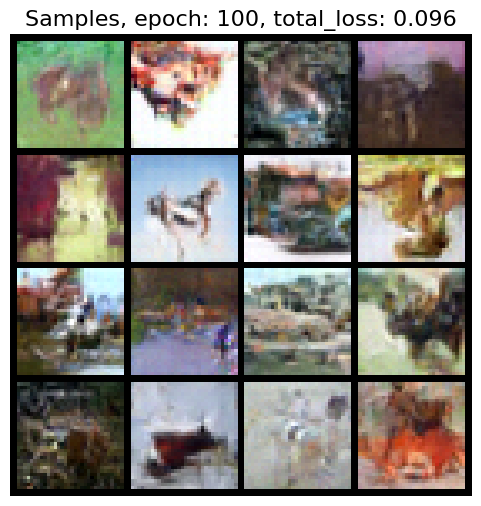

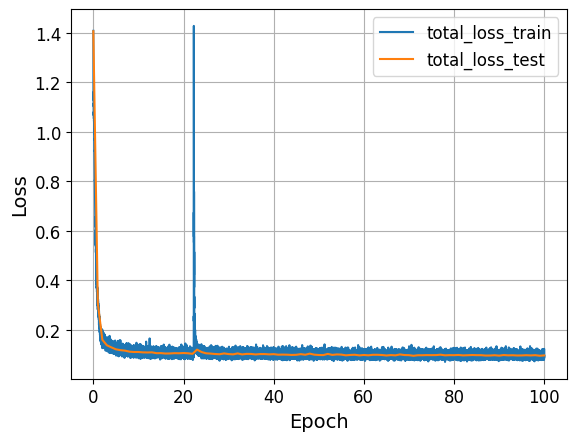

End of the training


In [9]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 
LR = 
EPOCHS = 

HIDDEN_CHANNELS = 
NUM_BLOCKS = 

PATCH_SHAPE =
NUM_HEADS =
# ====

model = FlowMatchingModel(
    hidden_channels=HIDDEN_CHANNELS,
    num_blocks=NUM_BLOCKS,
    image_shape=(32, 32),
    patch_shape=PATCH_SHAPE,
    num_heads=NUM_HEADS,
    num_channels=3,
)

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE)

# choose any optimizer/scheduler as you want
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_model(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16,
    visualize_samples=True,
)

# you might want to save the model
# torch.save(model.state_dict(), "flow_matching_model.pth")

You should not expect results as strong as in the previous homeworks with U-Net, because DiT is based on Transformers, which usually require more data, longer training, and more careful tuning, although in general they can outperform convolutional models at scale.

Let's now sample images using different numbers of steps. With only 5 steps, the results are likely to be poor. In next tasks we will try to fix this problem.

In [10]:
model.eval()
model.to(DEVICE)

num_samples = 100
samples_5 = model.sample(n=num_samples, num_steps=5)
samples_100 = model.sample(n=num_samples, num_steps=100)

show_samples(samples_5, title="Samples with 5 steps")
show_samples(samples_100, title="Samples with 100 steps")

## Task 3: Rectified flow (2 pts) 

One way to address this issue is by fine-tuning the model using training pairs sampled from the model itself. This approach was introduced in Rectified Flow [paper](https://arxiv.org/abs/2209.03003). 

Specifically, the process involves first generating noise–image pairs $(\mathbf{x}_0^*, \mathbf{x}_1^*)$, which are then used to retrain the model. Mathematically speaking, for any convex cost function $c$ (e.g., $\|\cdot\|^2$), the expected displacement under the generated pairs is smaller than that of the original data:

$$
\mathbb{E}[c(\mathbf{x}_1^* - \mathbf{x}_0^*)] \leq \mathbb{E}[c(\mathbf{x}_1 - \mathbf{x}_0)].
$$

As a result, the ODE trajectories tend to be shorter and empirically more direct, which can improve numerical stability and reduce the number of steps required for accurate integration. This procedure could be repeated multilple times.

In [11]:
def prepare_dataset(
    model: BaseModel,
    num_steps: int,
    batch_size: int,
    train_size: int,
    test_size: int,
) -> Tuple[np.ndarray, ...]:
    train_noise = torch.randn(train_size, 3, 32, 32)
    test_noise = torch.randn(test_size, 3, 32, 32)

    train_x = np.empty_like(train_noise)
    test_x = np.empty_like(test_noise)
    
    # ====
    # your code
    # generate train and test samples
    
    # ====

    return train_x, train_noise, test_x, test_noise

In [12]:
# you might want to load the model
# model.load_state_dict(torch.load("flow_matching_model.pth"))

model.eval()
model.to(DEVICE)

train_x, train_noise, test_x, test_noise = prepare_dataset(
    model, 
    num_steps=10,
    batch_size=BATCH_SIZE,
    train_size=len(train_data), 
    test_size=len(test_data)
)
train_data = LabeledDataset(train_x, train_noise)
test_data = LabeledDataset(test_x, test_noise)

Now we can fine-tune the model.

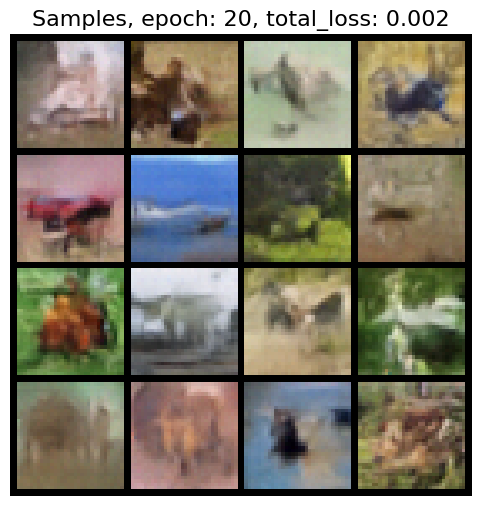

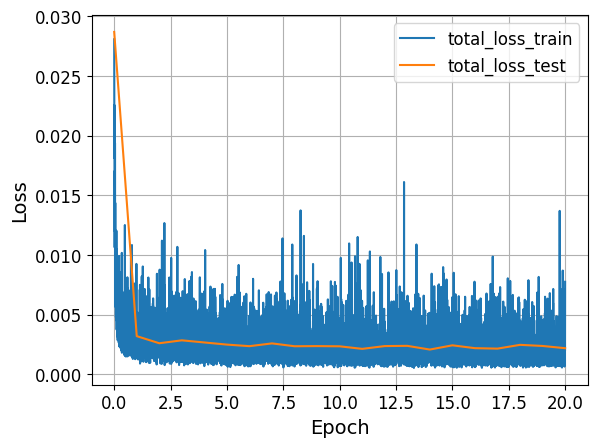

End of the training


In [13]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 
LR = 
EPOCHS = 
# ====

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE)

# choose any optimizer/scheduler as you want
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_model(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16,
    visualize_samples=True,
    conditional=True
)

Here, you should obtain higher-quality images even with 5-step generation and similar with 100-step.

In [14]:
model.eval()
model.to(DEVICE)

num_samples = 100
samples_5 = model.sample(n=num_samples, num_steps=5)
samples_100 = model.sample(n=num_samples, num_steps=100)

show_samples(samples_5, title="Samples with 5 steps")
show_samples(samples_100, title="Samples with 100 steps")

## Task 3: Flow matching with OT couplings (3 pts) 

Another way to reduce displacement under a given cost function is through **optimal transport (OT)**. The goal is to ensure that the generated sample $\mathbf{x}_1$ remains close to the original noise $\mathbf{x}_0$, under a cost function $c(\mathbf{x}_0, \mathbf{x}_1)$, such as $\|\mathbf{x}_1 - \mathbf{x}_0\|^2$. This leads to minimizing the **Wasserstein distance** between the distributions:

$$
W(p_0, p_1) = \inf_{\pi \in \Pi(p_0, p_1)} \mathbb{E}_{(\mathbf{x}_0, \mathbf{x}_1) \sim \pi}[\|\mathbf{x}_0 - \mathbf{x}_1\|^2],
$$

where $\Pi(p_0, p_1)$ is the set of all couplings with marginals $p_0$ and $p_1$.

In practice we skip the costly full-dataset OT and work inside each mini-batch. We treat the batch of images $ \{\mathbf{x}_0^{i}\}_{i=1}^{B}$ and the batch of noise $ \{\mathbf{x}_1^{j}\}_{j=1}^{B}$ as a vectors from uniform distributions $\mathbf{a}$ and $\mathbf{b}$. Next, we form the cost matrix $M_{ij} = \|\mathbf{x}_0^{i} - \mathbf{x}_1^{j}\|^{2}$ and find Wasserstein distance:

$$
\pi^\star = \arg\min_{\pi \in \Pi(\mathbf{a},\mathbf{b})} \langle \pi, M \rangle,
$$

to get the optimal transport plan $\pi^\star$.

We then sample index pairs $(i,j)$ according to the weights in $\pi^\star$ and train on the matched pairs $(\mathbf{x}_0^{i}, \mathbf{x}_1^{j})$. This keeps each image close to a nearby noise point, shrinking the mini-batch Wasserstein distance. For more, see [paper](https://arxiv.org/abs/2304.14772).


In [15]:
train_data, train_labels, test_data, test_labels = load_dataset("cifar10", flatten=False, binarize=False, with_targets=True)
visualize_images(train_data, "CIFAR10 samples")

Instead of coding an OT solver from scratch, we’ll rely on the [POT library](https://pythonot.github.io/).

In [16]:
class FlowMatchingOTModel(FlowMatchingModel):
    def get_map(self, x: torch.Tensor, y: torch.Tensor):
        # ====
        # your code
        # 1) covert x and y to vectors
        # 2) apply Earth Movers distance solver with L2 cost matrix
        # NOTE: treat x and y as elements from uniform distribution
        
        # ====
        return p

    def sample_map(self, pi, batch_size):
        p = pi.flatten()
        p = p / p.sum()
        choices = np.random.choice(pi.shape[0] * pi.shape[1], p=p, size=batch_size)
        return np.divmod(choices, pi.shape[1])

    def sample_plan(self, x: torch.Tensor, y: torch.Tensor):
        pi = self.get_map(x, y)
        i, j = self.sample_map(pi, x.shape[0])
        return x[i], y[j]

    def loss(
        self, 
        x: torch.Tensor, 
        y: Optional[torch.Tensor] = None
    ) -> Dict[str, torch.Tensor]:
        if y is None:
            y = torch.randn_like(x, device=self.device)

        # ====
        # your code
        # 1) sample time uniformly from 0 to 1
        # 2) permute x and y using OT
        # 3) calculate x_t and optimal flow
        # 4) predict flow using model
        # 5) calculate loss
        
        # ====
        return {'total_loss': loss}


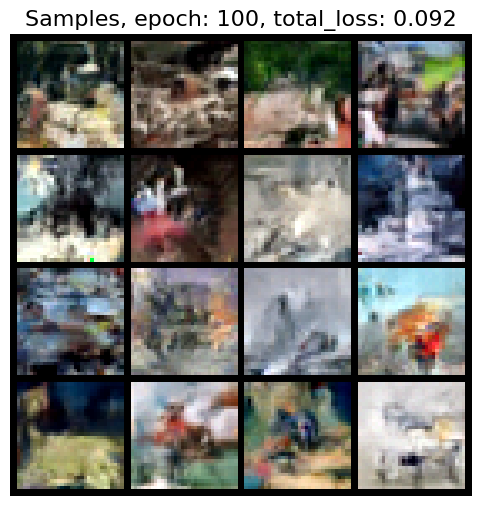

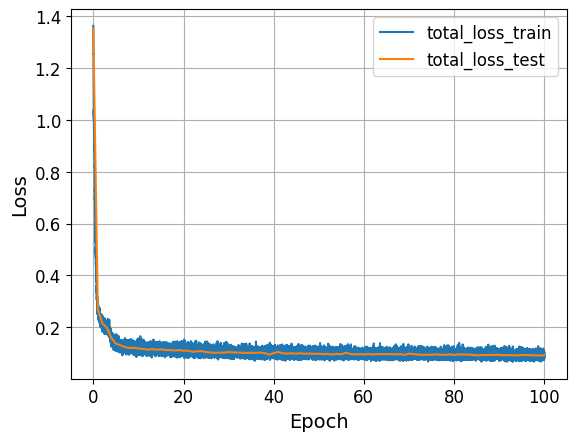

End of the training


In [17]:
# ====
А
# choose these parameters
BATCH_SIZE = 
LR = 
EPOCHS = 

HIDDEN_CHANNELS = 
NUM_BLOCKS = 

PATCH_SHAPE = 
NUM_HEADS = 
# ====

model = FlowMatchingOTModel(
    hidden_channels=HIDDEN_CHANNELS,
    num_blocks=NUM_BLOCKS,
    image_shape=(32, 32),
    patch_shape=PATCH_SHAPE,
    num_heads=NUM_HEADS,
    num_channels=3,
)

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE)

# choose any optimizer/scheduler as you want
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_model(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16,
    visualize_samples=True,
)

With just five steps, the samples should improve over the original Flow matching baseline, but they’ll still fall short of the quality achieved by Rectified flow.

In [18]:
model.eval()
model.to(DEVICE)

num_samples = 100
samples_5 = model.sample(n=num_samples, num_steps=5)
samples_100 = model.sample(n=num_samples, num_steps=100)

show_samples(samples_5, title="Samples with 5 steps")
show_samples(samples_100, title="Samples with 100 steps")